### Well near leaky fault

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.special import erfcx, exp1

import timflow.transient as tft

In [1]:
"""
Head around a pumping well near a leaky (semipermeable) fault.

Solution of Yaxley (1987, SPE Formation Evaluation, SPE-14311-PA), rewritten in
terms of hydraulic head and a numerically stable form (erfcx).

Geometry : fault is the plane x = 0, well at (x, y) = (d, 0), d > 0.
Aquifer  : same T and S on both sides, initial head h0, constant rate Q.
Fault    : leakage per unit fault length q_f = C * (h(x<0) - h(x>0)),
           C = H / c_f  [L/T]  (c_f = l_f / K_f [T], H = aquifer thickness [L]).

Consistent units are required (e.g. m, d):  T [L2/T], S [-], Q [L3/T], C [L/T].
"""

In [2]:
def htheis(r, t, T, S, Q, t0=0):
    return -Q / (4 * np.pi * T) * exp1(S * r**2 / (4 * T * (t - t0)))


def _leak_integral(R2, xd, t, T, S, C):
    """
    Integral.

    L = int_0^t exp[-S*R2/(4*T*tau)] * erfcx(z) dtau/sqrt(tau),
    z = 2*C*sqrt(tau)/sqrt(T*S) + (xd/2)*sqrt(S/(T*tau)),
    with xd = |x| + d and R2 = (|x|+d)^2 + y^2.
    Substituting tau = t*v^2 removes the 1/sqrt(tau) singularity:
    L = 2*sqrt(t) * int_0^1 f(t*v^2) dv.
    """

    def f(v):
        if v <= 0.0:
            return 0.0
        tau = t * v * v
        z = 2.0 * C * np.sqrt(tau) / np.sqrt(T * S) + 0.5 * xd * np.sqrt(S / (T * tau))
        e = -S * R2 / (4.0 * T * tau)
        if e < -745.0:  # exp underflows to 0
            return 0.0
        return np.exp(e) * erfcx(z)

    val, _ = quad(f, 0.0, 1.0, epsabs=0.0, epsrel=1e-9, limit=200)
    return 2.0 * np.sqrt(t) * val


def head_leaky_fault(x, y, t, Q, T, S, C, d, h0=0.0):
    """
    Well near fault.

    Hydraulic head h(x, y, t) near a well at (d, 0) pumping at rate Q
    beside a leaky fault at x = 0.

    Parameters
    ----------
    x, y : float or array   coordinates [L]
    t    : float            time since pumping started [T] (> 0)
    Q    : pumping rate [L3/T] (positive = extraction)
    T, S : transmissivity [L2/T], storativity [-]
    C    : fault conductance H/c_f [L/T]; C=0 -> sealing, C=inf -> no fault
    d    : distance well-fault [L]
    h0   : initial head

    Returns head (same shape as broadcast x, y).
    """
    x, y = np.broadcast_arrays(np.asarray(x, float), np.asarray(y, float))
    out = np.empty(x.shape)
    pref = Q / (4.0 * np.pi * T)

    for idx in np.ndindex(x.shape):
        xi, yi = x[idx], y[idx]
        xd = abs(xi) + d
        R2 = xd**2 + yi**2
        if C == 0.0:
            leak = 0.0
        elif np.isinf(C):
            leak = None  # handled below (Theis limit)
        else:
            leak = (Q * C / (2.0 * np.sqrt(np.pi) * T**1.5 * S**0.5)) * _leak_integral(
                R2, xd, t, T, S, C
            )

        u1 = S * ((xi - d) ** 2 + yi**2) / (4.0 * T * t)
        u2 = S * ((xi + d) ** 2 + yi**2) / (4.0 * T * t)

        if leak is None:  # no fault: Theis
            out[idx] = h0 - pref * exp1(u1)
        elif xi > 0:  # well side
            out[idx] = h0 - pref * (exp1(u1) + exp1(u2)) + leak
        elif xi < 0:  # far side
            out[idx] = h0 - leak
        else:  # on the fault: both sides differ
            out[idx] = np.nan  # head jumps across fault; use x=+/-eps
    return out if out.shape else float(out)


def head_pumping_well(t, Q, T, S, C, d, rw, h0=0.0):
    """Head in the pumping well (x = d - rw, y = 0, rw << d)."""
    t = np.atleast_1d(np.asarray(t, float))
    res = np.empty_like(t)
    for i, ti in enumerate(t):
        theis = exp1(S * rw**2 / (4 * T * ti)) + exp1(S * d**2 / (T * ti))
        if C == 0.0:
            leak = 0.0
        else:
            leak = (Q * C / (2 * np.sqrt(np.pi) * T**1.5 * S**0.5)) * _leak_integral(
                4 * d**2, 2 * d, ti, T, S, C
            )  # xd=|x|+d=2d, R2=4d^2 at x=d
        res[i] = h0 - Q / (4 * np.pi * T) * theis + leak
    return res if res.size > 1 else float(res[0])


def late_time_offset(Q, T, C, d):
    """Constant extra drawdown at the pumping well vs. the no-fault Theis line.

    ds = Q/(2 pi T) * exp(X) * E1(X), X = 4 C d / T  (computed stably).
    """
    X = 4.0 * C * d / T
    # exp(X)*E1(X) = erfcx-type scaling; use exp1 directly for moderate X,
    # asymptotic series for large X.
    if X < 500:
        f = np.exp(X) * exp1(X)
    else:
        f = (1.0 / X) * (1 - 1 / X + 2 / X**2 - 6 / X**3)
    return Q / (2 * np.pi * T) * f


if __name__ == "__main__":
    # --- example / sanity checks -----------------------------------------
    Q, T, S, d, h0 = 1000.0, 500.0, 1e-3, 100.0, 0.0  # m3/d, m2/d, -, m, m
    t = 1.0  # d

    def theis(r, t):
        return h0 - Q / (4 * np.pi * T) * exp1(S * r**2 / (4 * T * t))

    # 1) C -> large : Theis on both sides
    for xo in (150.0, -50.0):
        print(
            "C=1e9  x=%6.1f  h=%.6f  Theis=%.6f"
            % (
                xo,
                head_leaky_fault(xo, 20.0, t, Q, T, S, 1e9, d, h0),
                theis(np.hypot(xo - d, 20.0), t),
            )
        )

    # 2) C -> small : image-well solution, far side ~ h0
    xo = 150.0
    img = h0 - Q / (4 * np.pi * T) * (
        exp1(S * ((xo - d) ** 2 + 400) / (4 * T * t))
        + exp1(S * ((xo + d) ** 2 + 400) / (4 * T * t))
    )
    print(
        "C=1e-9 x=150 h=%.6f  image=%.6f"
        % (head_leaky_fault(xo, 20.0, t, Q, T, S, 1e-9, d, h0), img)
    )

    # 3) intermediate conductance, profile along y = 0 (also x >> d is stable)
    C = 20.0  # m/d
    xs = np.array([-300, -100, -10, 10, 100, 150, 300, 1000, 5000.0])
    print(np.c_[xs, head_leaky_fault(xs, 0.0, t, Q, T, S, C, d, h0)])

C=1e9  x= 150.0  h=-0.948631  Theis=-0.948631
C=1e9  x= -50.0  h=-0.621336  Theis=-0.621336
C=1e-9 x=150 h=-1.412304  image=-1.412304
[[-3.00000000e+02 -3.13730155e-01]
 [-1.00000000e+02 -5.15553432e-01]
 [-1.00000000e+01 -6.89481231e-01]
 [ 1.00000000e+01 -8.18096594e-01]
 [ 1.00000000e+02            -inf]
 [ 1.50000000e+02 -9.86897166e-01]
 [ 3.00000000e+02 -5.42785851e-01]
 [ 1.00000000e+03 -1.12392068e-01]
 [ 5.00000000e+03 -7.68549509e-08]]


In [112]:
k = 10  # m/d
H = 10  # m
S = 0.1  # -
cf = 10  # 1 m wide with k=0.1 m/d, d
d = 50  # m
Q = 500  # m^3/d
rw = 0.3
#
T = k * H  # m^2 / d
C = H / cf  # m/d

In [91]:
ngr = 50
xg = np.hstack((np.linspace(-100, -0.01, ngr), np.linspace(0.01, 100, ngr)))
yg = np.linspace(-100, 100, ngr)

x, y = np.meshgrid(xg, yg)
t = 100
h = head_leaky_fault(x, y, t, Q, T, S, C, d)

In [92]:
h.min()

np.float64(-4.522572853233762)

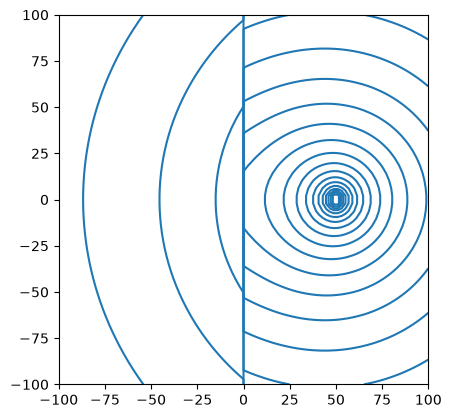

In [96]:
plt.subplot(111, aspect=1)
plt.contour(x, y, h, np.arange(-10, 0, 0.2), colors="C0")

In [97]:
h.min()

np.float64(-4.522572853233762)

In [98]:
t = 10
head_pumping_well(t, Q, T, S, C, d, rw=0.3)

-5.1243046306677655

In [99]:
htheis(0.3, t, T, S, Q)

np.float64(-4.944692190060354)

In [100]:
1 / 0.01

100.0

In [101]:
late_time_offset(Q, T, C, d)

np.float64(0.28753617729159164)

In [102]:
ml = tft.ModelMaq(kaq=k, z=[H, 0], Saq=S, topboundary="phreatic", tmin=1, tmax=100)
w = tft.Well(ml, d, 0, rw=0.3, tsandQ=[(0, Q)])
tft.LeakyWallString(ml, xy=[(0, -1000), (0, -100), (0, 100), (0, 1000)], res=cf, order=8)
ml.solve()

self.neq  28
solution complete


In [103]:
w.headinside(10)

array([[-5.12372975]])

In [104]:
ht = ml.headgrid(xg, yg, t=100, parallel=True)

head array: 100%|████████████████████████| 5000/5000 [00:03<00:00, 1609.10it/s]


In [105]:
ht.shape

(1, 1, 50, 100)

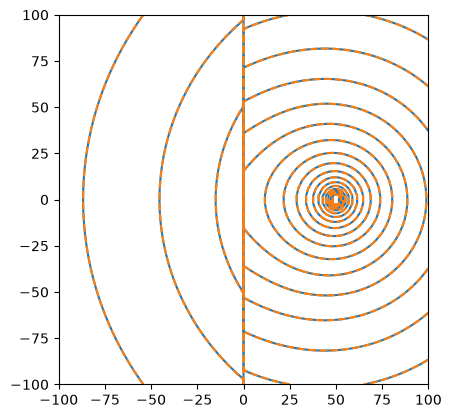

In [108]:
plt.subplot(111, aspect=1)
plt.contour(x, y, h, np.arange(-10, 0, 0.2), colors="C0")
plt.contour(x, y, ht[0, 0], np.arange(-10, 0, 0.2), colors="C1", linestyle="--")

In [89]:
w.headinside(100)

array([[-1.22670511]])

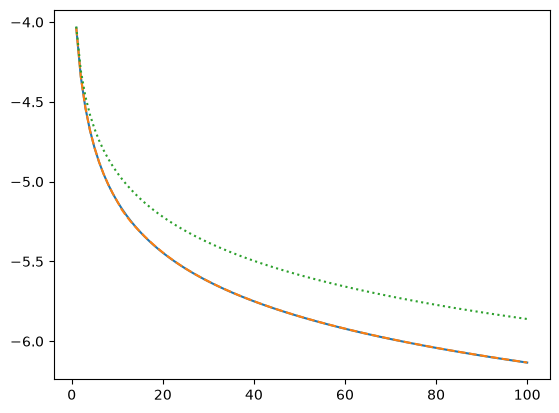

In [117]:
t = np.linspace(1, 100, 100)
hexact = head_pumping_well(t, Q, T, S, C, d, rw)
h = w.headinside(t)
hnowall = htheis(rw, t, T, S, Q)
plt.plot(t, hexact)
plt.plot(t, h[0], "--")
plt.plot(t, hnowall, ":")

In [ ]:
ht